BMP（Bitmap）是微软公司开发的一种标准数字化图像文件格式，广泛应用于 Windows 操作系统。它最核心的特点是简单直观：基本上是直接将图像的像素数据存储在硬盘上，不进行复杂压缩。
## 1. BMP 文件的四个核心组成部分

一个标准的 BMP 文件（如你上传的 7.bmp）在二进制层面由以下四部分组成：

| 组成部分 | 作用 | 内容示例 |
|----------|------|----------|
| 文件头 (File Header) | “身份证” | 标识这是 BMP 文件，记录文件总大小。 |
| 信息头 (DIB Header) | “规格说明书” | 记录图像的宽度、高度、位深度（颜色数）。 |
| 调色板 (Palette) | “颜料盒” | 灰度图或低彩色图中，记录索引值对应的具体颜色。 |
| 像素数据 (Pixel Data) | “正文内容” | 每一个像素点的具体颜色数值。 |

## 2. 以 7.bmp 为例的深度解析

根据你上传的图像，我们可以推断出它的具体技术参数。这类图像通常用于深度学习（如手写数字识别）：

### A. 基础规格

尺寸： $28 \times 28$ 像素。颜色模式：8 位灰度图（Grayscale）。位深度：8-bit（意味着每个像素由 1 个字节表示，数值范围 $0 \sim 255$）。

### B. 存储特性：4 字节对齐

BMP 要求每一行像素占用的字节数必须是 4 的倍数。对于 7.bmp：宽度为 28 像素 $\times$ 1 字节/像素 = 28 字节。由于 28 正好能被 4 整除，因此这幅图在存储时不需要填充额外的空字节。

### C. 存储方向：自底向上

这是一个最容易被忽略的细节：BMP 的像素是从左下角开始记录，一行行向上移动，直到右上角。注意：如果你直接读取原始数据而不进行翻转，图像在神经网络处理时可能是倒着的。

## 3. BMP 与神经网络常用数组的对比

当你使用 Python（如 NumPy）读取图像时，你会得到一个数组，它与硬盘里的 BMP 文件存在细微差别：

- **通道顺序**：BMP 在处理彩色图时习惯使用 BGR 顺序，而神经网络通常期待 RGB。
- **数据结构**：
  - 内存数组：通常是紧凑的 (H, W, C) 结构。
  - BMP 文件：除了像素外，还带有头部信息和可能的填充字节（Padding）。
- **无损性**：BMP 是完全无损的。7.bmp 中看到的模糊边缘并非格式压缩导致，而是图像生成时为了平滑效果特意保留的灰度过渡。

**总结**

BMP 格式虽然体积大，但因为它结构透明、无需解压，非常适合作为计算机底层处理和算法训练的初始素材。


图像已保存为 lena_quantize_result.png


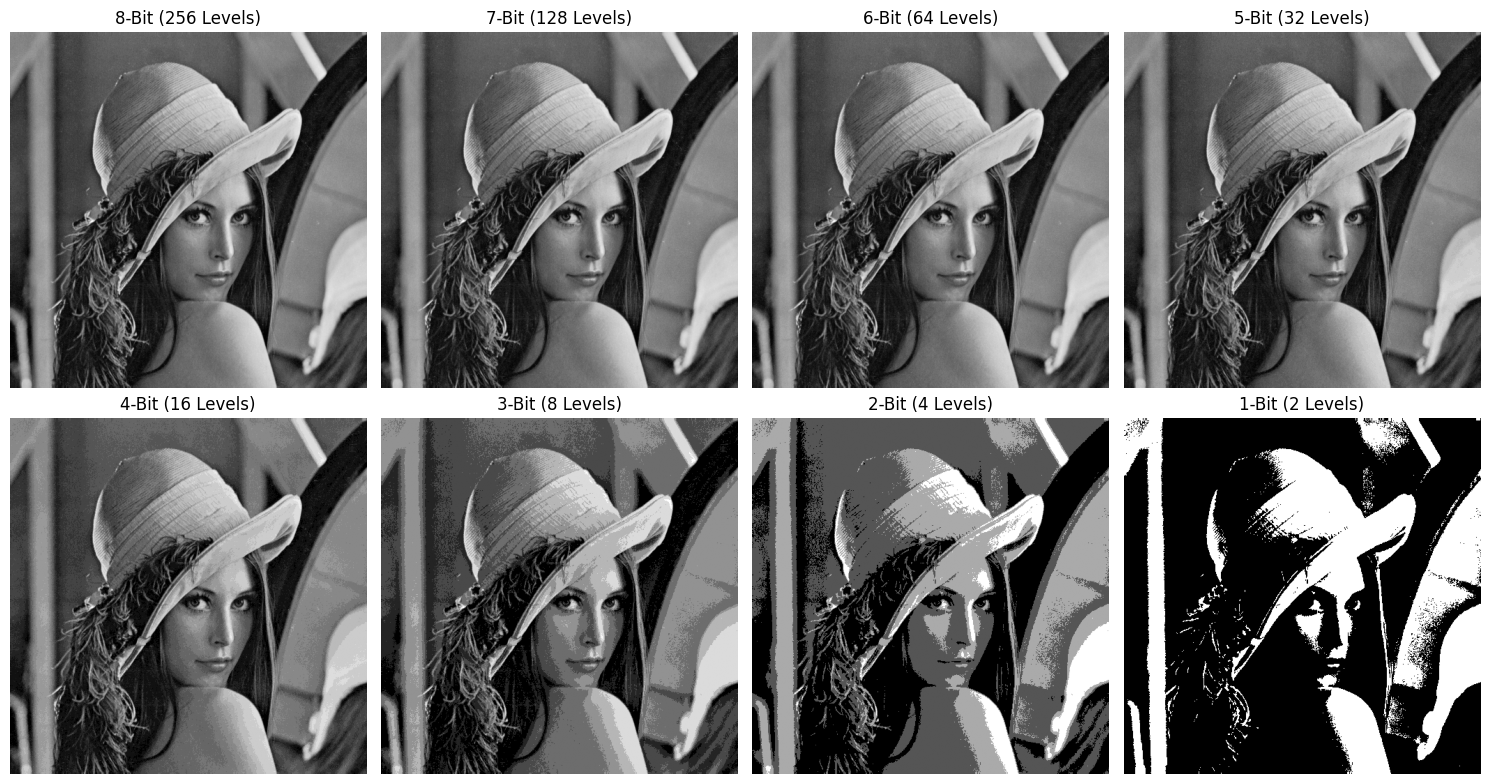

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def reduce_gray_levels(image, bit):
    # 1. 计算当前位下的级别数，例如 1-bit 为 2 级，4-bit 为 16 级
    levels = 2 ** bit
    
    # 2. 缩放像素值
    # 先归一化到 0 ~ (levels-1)，再拉伸回 0~255
    factor = 256 // levels
    reduced_img = (image // factor) * (255 // (levels - 1))
    
    return reduced_img.astype(np.uint8)

# 读取图像（确保是 512x512 的灰度图）
img = cv2.imread('lena.bmp', cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (512, 512))

# 显示 8 到 1 bit 的变化
plt.figure(figsize=(15, 8))
for i in range(8, 0, -1):
    plt.subplot(2, 4, 9-i)
    processed = reduce_gray_levels(img, i)
    plt.imshow(processed, cmap='gray')
    plt.title(f'{i}-Bit ({2**i} Levels)')
    plt.axis('off')

plt.tight_layout()
# plt.savefig('lena_quantize_result.png', dpi=300, bbox_inches='tight')
# print("图像已保存为 lena_quantize_result.png")
plt.show()

In [ ]:
import cv2
import numpy as np

# 1. 读取图像，确保以灰度模式读取
img = cv2.imread('lena.bmp', cv2.IMREAD_GRAYSCALE)

# 2. 使用 numpy 计算
mean_val = np.mean(img)
var_val = np.var(img)
std_dev = np.std(img) # 标准差

print(f"Lena 图像的均值: {mean_val:.2f}")
print(f"Lena 图像的方差: {var_val:.2f}")
print(f"Lena 图像的标准差: {std_dev:.2f}")

Lena 图像的均值: 99.05
Lena 图像的方差: 2796.03
Lena 图像的标准差: 52.88


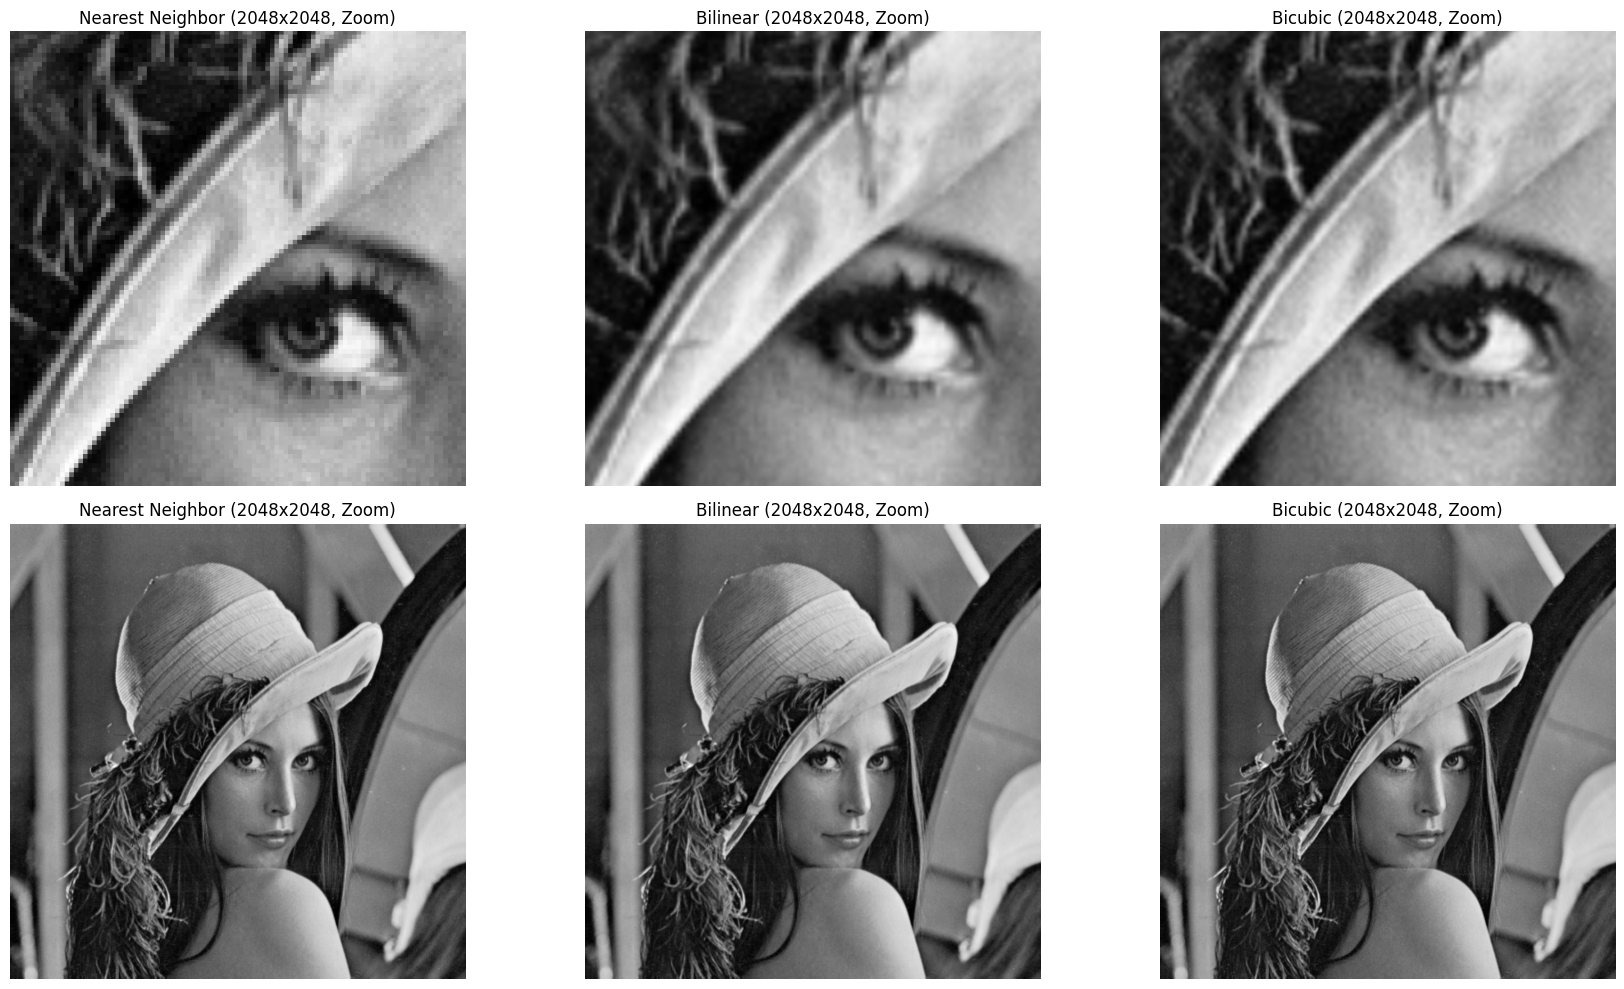

In [1]:
import cv2
import matplotlib.pyplot as plt

# 1. 读取原始 Lena 图像
# 确保文件路径正确，通常是灰度图
img = cv2.imread('lena.bmp', cv2.IMREAD_GRAYSCALE)

# 检查图像是否成功读取
if img is None:
    raise FileNotFoundError("无法加载 lena.bmp，请检查路径。")

# 2. 定义目标尺寸 (2048x2048)
target_size = (2048, 2048)

# 3. 执行三种插值放大
# 方法1：最近邻插值
img_nearest = cv2.resize(img, target_size, interpolation=cv2.INTER_NEAREST)

# 方法2：双线性插值
img_linear = cv2.resize(img, target_size, interpolation=cv2.INTER_LINEAR)

# 方法3：双三次插值
img_cubic = cv2.resize(img, target_size, interpolation=cv2.INTER_CUBIC)

# 4. 可视化对比（局部放大以展示细节差异）
zoom_region = (200, 300, 200, 300) # (y_start, y_end, x_start, x_end) 在原图的位置
scale_factor = target_size[0] // img.shape[0] # 放大倍数，这里是 4
z_y_start, z_y_end, z_x_start, z_x_end = [v * scale_factor for v in zoom_region]

plt.figure(figsize=(18, 10))

# 显示最近邻结果（局部）
plt.subplot(2, 3, 1)
plt.imshow(img_nearest[z_y_start:z_y_end, z_x_start:z_x_end], cmap='gray')
plt.title(f'Nearest Neighbor (2048x2048, Zoom)')
plt.axis('off')

# 显示双线性结果（局部）
plt.subplot(2, 3, 2)
plt.imshow(img_linear[z_y_start:z_y_end, z_x_start:z_x_end], cmap='gray')
plt.title(f'Bilinear (2048x2048, Zoom)')
plt.axis('off')

# 显示双三次结果（局部）
plt.subplot(2, 3, 3)
plt.imshow(img_cubic[z_y_start:z_y_end, z_x_start:z_x_end], cmap='gray')
plt.title(f'Bicubic (2048x2048, Zoom)')
plt.axis('off')

# 显示最近邻结果（全部）
plt.subplot(2, 3, 4)
plt.imshow(img_nearest, cmap='gray')
plt.title(f'Nearest Neighbor (2048x2048, Zoom)')
plt.axis('off')

# 显示双线性结果（全部）
plt.subplot(2, 3, 5)
plt.imshow(img_linear, cmap='gray')
plt.title(f'Bilinear (2048x2048, Zoom)')
plt.axis('off')

# 显示双三次结果（全部）
plt.subplot(2, 3, 6)
plt.imshow(img_cubic, cmap='gray')
plt.title(f'Bicubic (2048x2048, Zoom)')
plt.axis('off')

plt.tight_layout()
plt.show()

# 5. 保存结果文件
# cv2.imwrite('lena_nearest_2048.bmp', img_nearest)
# cv2.imwrite('lena_linear_2048.bmp', img_linear)
# cv2.imwrite('lena_cubic_2048.bmp', img_cubic)

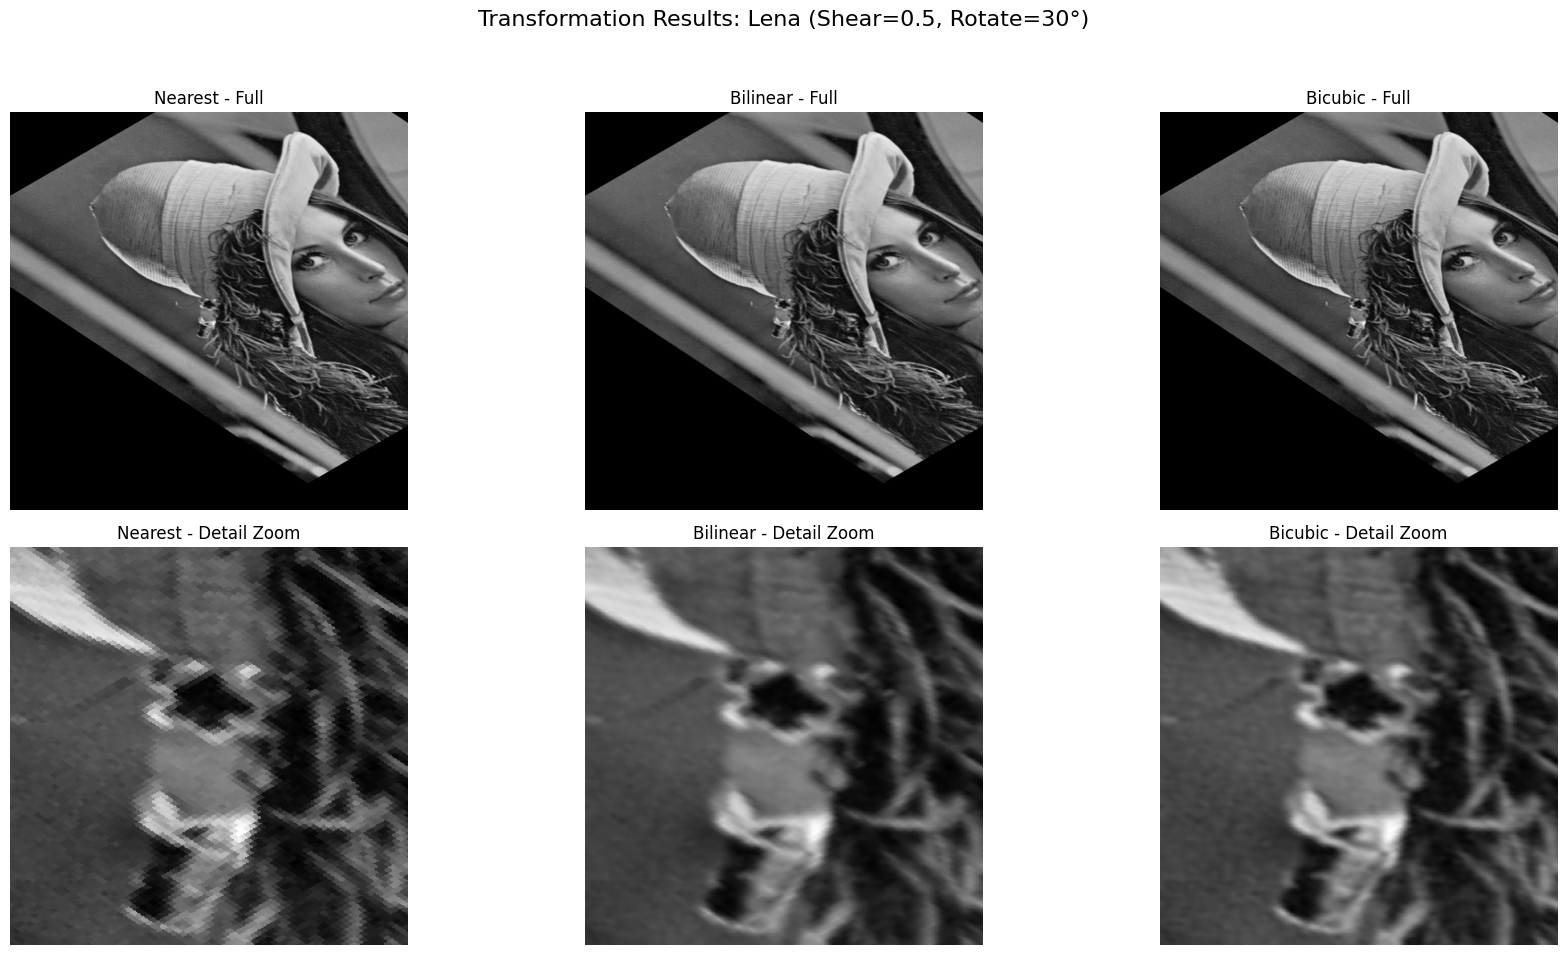

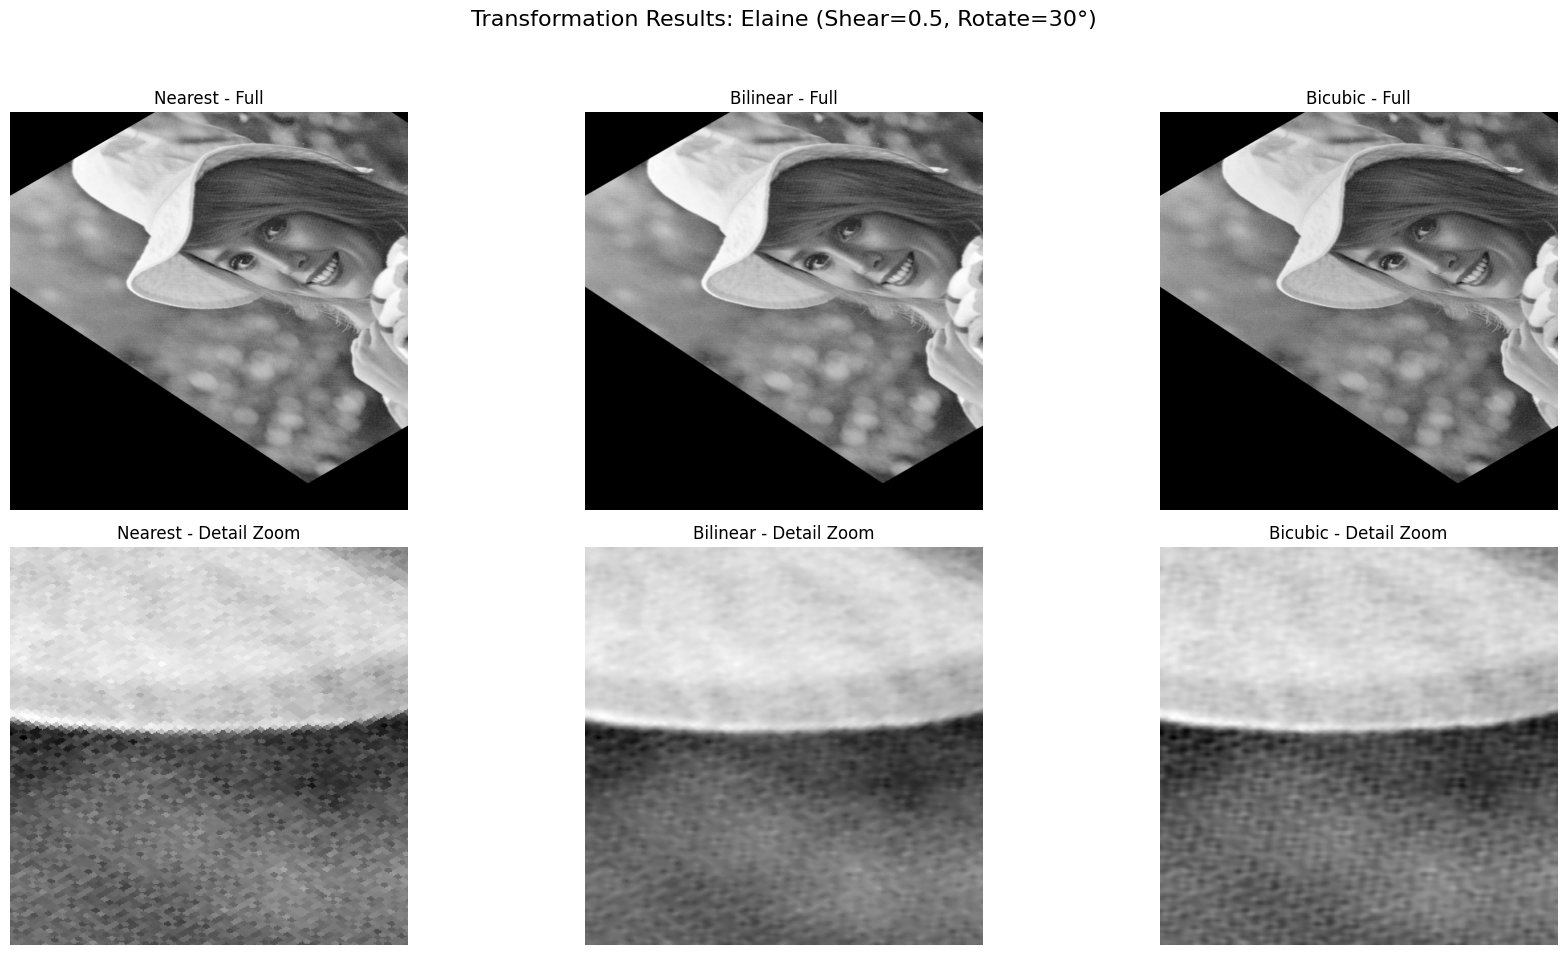

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def process_and_show(img_path, title_name):
    # 1. 读取图像
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"跳过：未找到文件 {img_path}")
        return

    # 2. 设置参数
    rows, cols = img.shape
    target_size = (2048, 2048)
    angle = 30
    shear_factor = 0.5  # 建议0.2-0.5，1.5会导致图像严重超出边界
    
    # 3. 构建复合变换矩阵
    # 旋转矩阵
    M_rot = cv2.getRotationMatrix2D((cols/2, rows/2), angle, 1)
    # 剪切矩阵
    M_shear = np.float32([[1, shear_factor, 0], [0, 1, 0]])
    # 组合矩阵 (旋转 * 剪切)
    M_combined = np.dot(M_rot[:, :2], M_shear[:, :2])
    M_combined = np.column_stack((M_combined, M_rot[:, 2]))
    
    # 为了放大到2048，我们需要在矩阵中加入缩放比例
    scale = target_size[0] / rows
    M_final = M_combined * scale

    # 4. 使用三种插值法进行变换
    methods = [
        ("Nearest", cv2.INTER_NEAREST),
        ("Bilinear", cv2.INTER_LINEAR),
        ("Bicubic", cv2.INTER_CUBIC)
    ]
    
    results = []
    for name, flag in methods:
        res = cv2.warpAffine(img, M_final, target_size, flags=flag)
        results.append((name, res))

    # 5. 可视化：2行3列
    # 第一行：全图对比；第二行：局部细节对比
    plt.figure(figsize=(18, 10))
    plt.suptitle(f"Transformation Results: {title_name} (Shear={shear_factor}, Rotate={angle}°)", fontsize=16)
    
    # 定义局部放大的坐标（针对2048尺寸，取中心区域）
    cx, cy = 1024, 1024
    r = 150 # 截取半径
    
    for i, (name, res_img) in enumerate(results):
        # 第一行：显示全图
        plt.subplot(2, 3, i + 1)
        plt.imshow(res_img, cmap='gray')
        plt.title(f"{name} - Full")
        plt.axis('off')
        
        # 第二行：显示局部细节 (Zoom)
        plt.subplot(2, 3, i + 4) # 索引 4, 5, 6 对应第二行
        plt.imshow(res_img[cy-r:cy+r, cx-r:cx+r], cmap='gray')
        plt.title(f"{name} - Detail Zoom")
        plt.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# 执行处理
process_and_show('lena.bmp', 'Lena')
process_and_show('elain1.bmp', 'Elaine')